# 04. DL-модели через neuralforecast

Сравнение 3 методов глубокого обучения для прогнозирования временного ряда.

Используются:

- NBEATS;
- NHITS;
- LSTM.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import (
    load_series,
    infer_frequency,
    split_series,
    to_nixtla_df,
    forecast_metrics,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
TARGET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'international-airline-passengers.csv'
series = load_series(TARGET_PATH, name='airline_passengers')

freq = infer_frequency(series)
train, test = split_series(series, test_size=12)
h = len(test)

train_df = to_nixtla_df(train, unique_id='airline_passengers')
print('freq:', freq, 'h:', h, 'train:', len(train_df))

freq: MS h: 12 train: 132


/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")


In [3]:
# При необходимости раскомментировать в Colab:
# !pip install neuralforecast torch -q

In [4]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, LSTM
from neuralforecast.losses.pytorch import MAE

# Для более точного результата можно увеличить max_steps.
models = [
    NBEATS(h=h, input_size=3*h, loss=MAE(), max_steps=100, random_seed=42),
    NHITS(h=h, input_size=3*h, loss=MAE(), max_steps=100, random_seed=42),
    LSTM(h=h, input_size=3*h, loss=MAE(), max_steps=100, random_seed=42),
]

nf = NeuralForecast(models=models, freq=freq)
nf.fit(df=train_df)
dl_pred = nf.predict()
dl_pred

Seed set to 42


Seed set to 42


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,NBEATS,NHITS,LSTM
0,airline_passengers,1960-01-01,433.720154,428.613190,403.634613
1,airline_passengers,1960-02-01,409.908844,439.831482,409.941376
2,airline_passengers,1960-03-01,466.509857,466.960205,430.692444
3,airline_passengers,1960-04-01,472.295288,469.419434,447.196198
4,airline_passengers,1960-05-01,479.463013,486.625702,474.122314
5,airline_passengers,1960-06-01,557.723816,552.540649,523.458984
6,airline_passengers,1960-07-01,640.686584,631.630127,593.271118
7,airline_passengers,1960-08-01,646.801941,649.132324,617.741638
8,airline_passengers,1960-09-01,550.630798,572.740601,542.803589
9,airline_passengers,1960-10-01,478.460571,479.093719,445.065613


**Вывод по обучению DL-моделей и таблице прогнозов.**

Обучены три нейросетевые модели: `NBEATS`, `NHITS` и `LSTM`. Все модели обучались с небольшим числом шагов (`max_steps=100`), поэтому результат нужно рассматривать как учебный benchmark, а не как полностью оптимизированную настройку. В логах видно, что GPU не использовался, обучение прошло на CPU. Полученная таблица содержит прогнозы на 12 месяцев тестового периода для каждой модели, что позволяет напрямую сравнить их с фактическими значениями.

In [5]:
metric_rows = []
model_cols = [c for c in dl_pred.columns if c not in ['unique_id', 'ds']]

for col in model_cols:
    metrics = forecast_metrics(test.values, dl_pred[col].values)
    metrics['model'] = col
    metrics['group'] = 'dl'
    metrics['comment'] = 'small max_steps for учебный запуск на CPU'
    metric_rows.append(metrics)

dl_metrics = pd.DataFrame(metric_rows).sort_values('RMSE')
dl_metrics.to_csv(REPORT_DIR / 'neuralforecast_comparison.csv', index=False)
dl_metrics

,MAE,RMSE,MAPE,sMAPE,model,group,comment
2,16.034388,18.012696,3.373305,3.368059,LSTM,dl,small max_steps for учебный запуск на CPU
0,26.136607,29.079010,5.613540,5.421713,NBEATS,dl,small max_steps for учебный запуск на CPU
1,29.403109,34.567871,6.425507,6.147645,NHITS,dl,small max_steps for учебный запуск на CPU


**Вывод по метрикам качества.**

Лучший результат среди DL-моделей показала `LSTM`: RMSE = 18.01, MAE = 16.03, MAPE = 3.37%. Это означает, что средняя абсолютная ошибка прогноза составляет около 16 пассажиров, а относительная ошибка - около 3.4%. `NBEATS` и `NHITS` дали более высокие ошибки: RMSE = 29.08 и 34.57 соответственно. В рамках данного запуска LSTM лучше уловила динамику ряда, но для окончательного вывода желательно проверить устойчивость результата на повторных запусках и при подборе гиперпараметров.

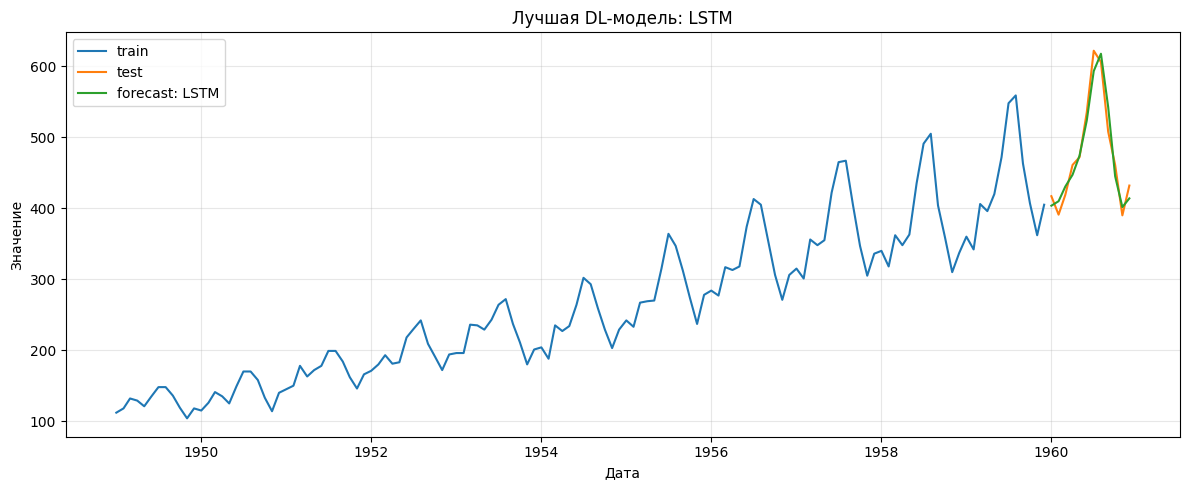

In [6]:
best_model = dl_metrics.iloc[0]['model']

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='train')
plt.plot(test.index, test.values, label='test')
plt.plot(test.index, dl_pred[best_model].values, label=f'forecast: {best_model}')
plt.title(f'Лучшая DL-модель: {best_model}')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_neuralforecast_model.png', dpi=150)
plt.show()

На графике прогноз `LSTM` в целом повторяет форму тестового участка: модель улавливает рост пассажиропотока к летним месяцам и последующее снижение к концу года. Основные расхождения заметны в уровне прогноза: в отдельных месяцах модель может немного занижать или завышать фактические значения. При этом визуально прогноз остается близким к тестовой кривой, что подтверждает хорошие значения MAE, RMSE и MAPE.

## Итоговый вывод

DL-блок успешно выполнен: модели `NBEATS`, `NHITS` и `LSTM` обучены через `NeuralForecast`, построены прогнозы на 12 месяцев и рассчитаны метрики качества.

По итогам текущего запуска лучшей стала `LSTM`:

- RMSE = 18.01;
- MAE = 16.03;
- MAPE = 3.37%;
- sMAPE = 3.37%.

`NBEATS` и `NHITS` показали более слабые результаты: RMSE = 29.08 и 34.57 соответственно. Это не означает, что эти архитектуры хуже в целом: в ноутбуке использован короткий учебный запуск с `max_steps=100`, без глубокого подбора параметров. На более длинном обучении и при настройке `input_size`, `max_steps`, learning rate и количества блоков результат может измениться.

По сравнению с предыдущим ML-блоком LSTM выглядит сильным кандидатом: ошибка низкая, прогноз визуально близок к фактическому тестовому периоду. Однако из-за малого размера ряда и более высокой стоимости обучения DL-модель стоит рассматривать не как безусловно лучший production-вариант, а как сильный экспериментальный benchmark.

Итог: для данного ряда простые статистические и ML-модели остаются хорошей базой, а `LSTM` можно использовать как дополнительную модель сравнения. Для финального выбора модели нужно объединить результаты всех ноутбуков, сравнить метрики на одном тестовом периоде и учитывать не только качество, но и сложность поддержки модели.